In [124]:
#Leggo dati

cas9_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_ko_2025/cetux_vs_egf_no3/trattamento_cutoff0.05-CETUX.vs.EGF0.1.deseq2.tsv'
#ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/327_creni_vs_EGF/trattamento_cutoff0.05-Creni_5uM_72h.vs.EGF0.1.deseq2.tsv'
cas9<-read.table(cas9_path,stringsAsFactors = FALSE, header = TRUE,row.names = 1)

creni_path_322<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/322_combo_vs_EGF/trattamento_cutoff0.05-Combo_72h.vs.EGF0.1.deseq2.tsv'
creni<-read.table(creni_path_322,stringsAsFactors = FALSE, header = TRUE,row.names = 1)
ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_ko_2025/cloni_cetux_vs_egf/trattamento_cutoff0.05-CETUX.vs.EGF0.1.deseq2.tsv'
#ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/327_creni_vs_EGF/trattamento_cutoff0.05-Creni_5uM_72h.vs.EGF0.1.deseq2.tsv'
ko<-read.table(ko_path,stringsAsFactors = FALSE, header = TRUE,row.names = 1)


## Definisco up down nei vari set + fisher test

          cas9-ko
cas9-combo not_in   in
    not_in    206  251
    in        461 1948


[1] 7.025995e-30

          cas9-ko
cas9-combo not_in   in
    not_in    199  174
    in        289 2692
[1] 1.903959e-104


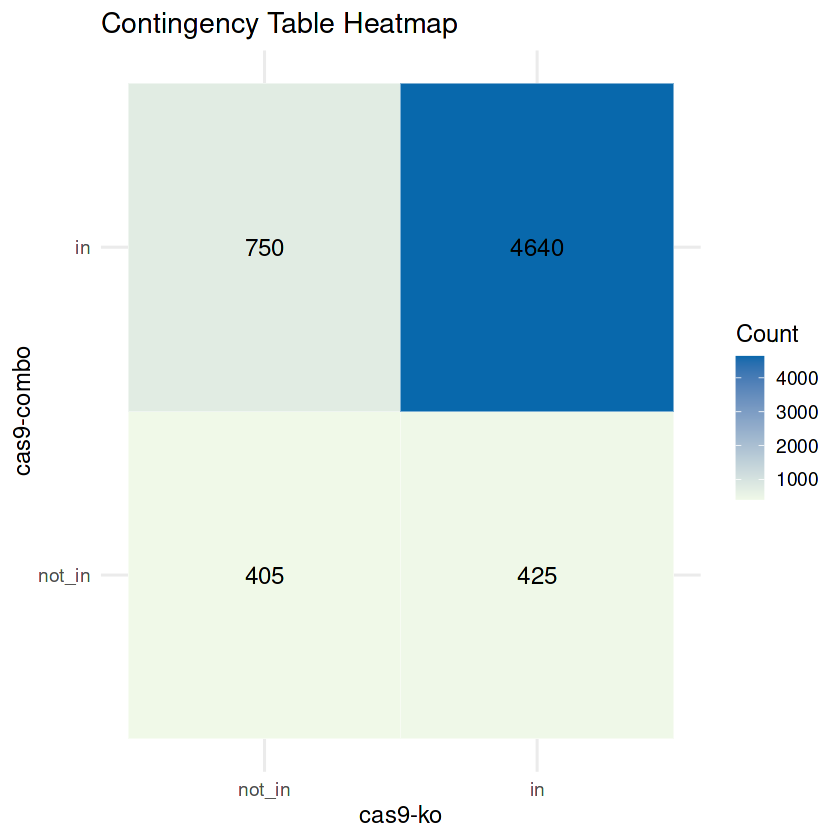

In [125]:
th_padj<-0.05
th_log2fc<-0

#selezioni i geni che sono significativi  nella cas9 cetux vs egf
cas9_up<-row.names(cas9[cas9$padj<th_padj &cas9$log2FoldChange>th_log2fc,]) 
cas9_down<-row.names(cas9[cas9$padj<th_padj &cas9$log2FoldChange<th_log2fc,])
all_cas9<-union(cas9_up,cas9_down)
#geni che si muovono up e down in combo
combo_up<-row.names(creni[creni$padj<th_padj &creni$log2FoldChange>th_log2fc,])
combo_down<-row.names(creni[creni$padj<th_padj &creni$log2FoldChange<th_log2fc,])
all_combo<-union(combo_up,combo_down)
#geni che si muovono in ko up e down
ko_up<-row.names(ko[ko$padj<th_padj &ko$log2FoldChange>th_log2fc,])
ko_down<-row.names(ko[ko$padj<th_padj &ko$log2FoldChange<th_log2fc,])
all_ko<-union(ko_up,ko_down)

##$$$$$$$$$$$$$$$$$$$$$$$$$$# logica Sofi originale su soli up rifatta
# universo: tutti i geni con dati nei confronti
universe_up <- intersect(cas9_up, intersect(rownames(ko), rownames(creni)))

# geni che si muovono in cas9 ma non in combo
cas9_combo_up <- setdiff(universe_up, combo_up)

# geni che si muovono in cas9 ma non in ko
cas9_ko_up <- setdiff(universe_up, ko_up)
#intersezioni
cas9_ko_common<-setdiff(universe_up,cas9_ko_up)
cas9_combo_common<-setdiff(universe_up,cas9_combo_up)


up_ns <-intersect(cas9_combo_up, cas9_ko_up)
a_up <-intersect(cas9_combo_up, cas9_ko_up)#si muovono solo in cas9 no ko no combo in entrambi
b_up <-  setdiff(cas9_combo_up,a_up)                           # solo in cas9-combo si muovono in cas9 ma non in combo
c_up <- setdiff(cas9_ko_up, a_up)                        # solo in cas9 ma non in ko, si muovono in cas9 ma non in ko
d_up <- setdiff(universe_up, union(union(a_up,b_up),c_up))       # 

contingency_table_up <- matrix(c(length(a_up), length(b_up), length(c_up),length( d_up)), nrow = 2, byrow=T,
                            dimnames = list("cas9-combo" = c("not_in", "in"),
                                            "cas9-ko" = c("not_in", "in")))

print(contingency_table_up)
prova<-fisher.test(contingency_table_up,alternative = 'greater')
prova$p.value
#DOWN 
# universo: tutti i geni con dati nei confronti
universe_down <- intersect(cas9_down, intersect(rownames(ko), rownames(creni)))

# geni che si muovono in cas9 ma non in combo
cas9_combo_down <- setdiff(universe_down, combo_down)
 
# geni che si muovono in cas9 ma non in ko
cas9_ko_down <- setdiff(universe_down, ko_down)


a_down <-intersect(cas9_combo_down, cas9_ko_down)#si muovono solo in cas9 no ko no combo in entrambi
b_down <-  setdiff(cas9_combo_down,a_down)                           # solo in cas9-combo si muovono in cas9 ma non in combo
c_down <- setdiff(cas9_ko_down, a_down)                        # solo in cas9 ma non in ko, si muovono in cas9 ma non in ko
d_down <- setdiff(universe_down, union(union(a_down,b_down),c_down))       # 

contingency_table_down <- matrix(c(length(a_down), length(b_down), length(c_down),length( d_down)), nrow = 2, byrow=T,
                            dimnames = list("cas9-combo" = c("not_in", "in"),
                                            "cas9-ko" = c("not_in", "in")))

print(contingency_table_down)


#fisher totale


contingency_table <- matrix(c(length(a_up)+length(a_down), length(b_up)+length(b_down), length(c_up)+length(c_down),length(d_up)+length(d_down)), nrow = 2, byrow=T,
                                 dimnames = list("cas9-combo" = c("not_in", "in"),
                                                 "cas9-ko" = c("not_in", "in")))


library(tidyverse)

df_long <- as.data.frame(as.table(contingency_table))
colnames(df_long) <- c("cas9_combo", "cas9_ko", "Freq")
ggplot(df_long, aes(x = cas9_ko, y = cas9_combo, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), color = "black", size = 5) +
  scale_fill_gradient(low = "#f0f9e8", high = "#0868ac") +
  labs(
    title = "Contingency Table Heatmap",
    x = "cas9-ko",
    y = "cas9-combo",
    fill = "Count"
  ) +
  theme_minimal(base_size = 14)
# Test di Fisher
fisher_result <- fisher.test(contingency_table,alternative = 'greater')
print(fisher_result$p.value)


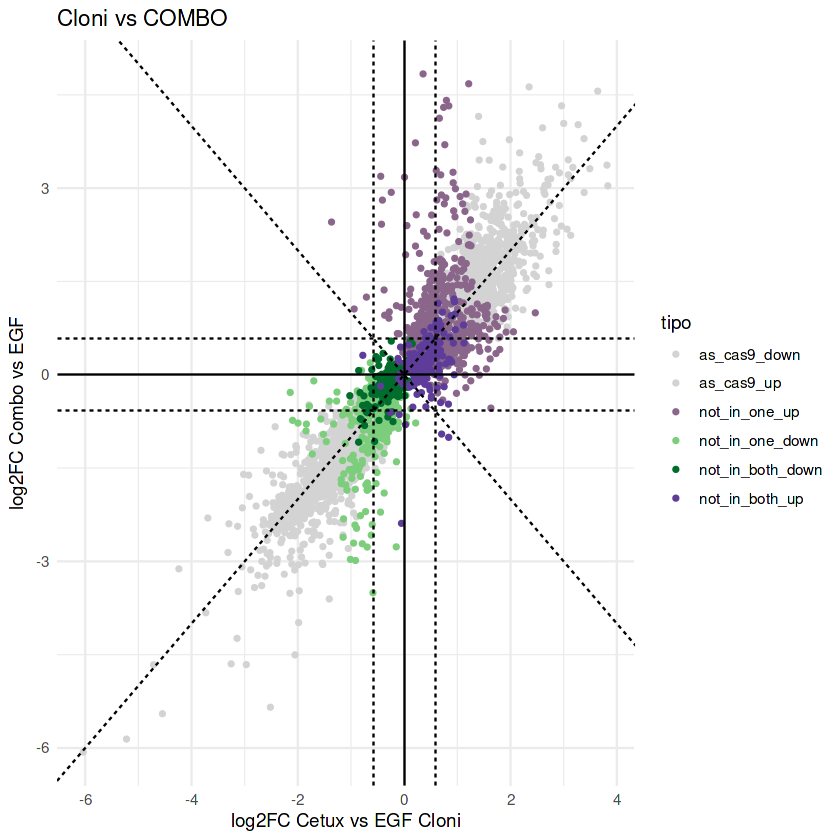

In [126]:
creni <- creni[, 'log2FoldChange', drop = FALSE]
ko <- ko[, 'log2FoldChange', drop = FALSE]


colnames(creni)<-'log2FC_CombovsEGF'
colnames(ko)<-'log2FC_CetuxvsEGF_cloni'
merged<-merge(creni,ko,by='row.names')
merged[is.na(merged)] <- 0
row.names(merged)<-merged$Row.names
merged$Row.names<-NULL
paneth_genes<-c('ATOH1','DLL1','DEFA5','GFI1','HES1')

universe<-union(universe_up,universe_down)
merged<-merged[universe,]
merged$tipo<-ifelse(rownames(merged)%in%a_up,'not_in_both_up',
                      ifelse(rownames(merged) %in% a_down,'not_in_both_down',ifelse(rownames(merged)%in% union(b_up,c_up),'not_in_one_up',ifelse(rownames(merged)%in% union(b_down,c_down),'not_in_one_down',ifelse(rownames(merged) %in% universe_up,'as_cas9_up','as_cas9_down')))))
merged$tipo <- factor(merged$tipo, levels = c("as_cas9_down", "as_cas9_up", 'not_in_one_up','not_in_one_down',"not_in_both_down", "not_in_both_up"))
merged <- merged[order(as.numeric(merged$tipo)), ]

scatter_plot <- ggplot(merged, aes(x = log2FC_CetuxvsEGF_cloni, 
                                   y = log2FC_CombovsEGF, 
                                   color = tipo)) +
  geom_point(size = 1) + 
  labs(title = 'Cloni vs COMBO',
       x = "log2FC Cetux vs EGF Cloni",
       y = "log2FC Combo vs EGF") +
  theme_minimal() + 
  scale_color_manual(values = c(
    "as_cas9_down" = "lightgrey",
    "not_in_both_down" = "#006d2c",
    "as_cas9_up" = "lightgrey",
    "not_in_both_up" = "#5e3c99",
    "not_in_one_up"="plum4",
    "not_in_one_down"="palegreen3"
    
    
  ))+
  geom_hline(yintercept = 0, color = "black", size = 0.5) + 
  geom_vline(xintercept = 0, color = "black", size = 0.5) + 
  geom_abline(intercept = 0, slope = 1, color = "black", linetype = "dashed", size = 0.5) + 
  geom_abline(intercept = 0, slope = -1, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) + 
  geom_hline(yintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) 

print(scatter_plot)

In [130]:
cas9 <- cas9[universe, 'log2FoldChange', drop = FALSE]
merged_prova<-merge(merged,cas9,by='row.names')
merged_prova['CrenivsCas9']<-merged_prova$log2FC_CombovsEGF-merged_prova$log2FoldChange
merged_prova['KOvsCas9']<-merged_prova$log2FC_CetuxvsEGF_cloni-merged_prova$log2FoldChange
merged_prova$tipo <- factor(merged_prova$tipo, levels = c("as_cas9_down", "as_cas9_up", 'not_in_one_up','not_in_one_down',"not_in_both_down", "not_in_both_up"))
merged_prova <- merged_prova[order(as.numeric(merged_prova$tipo)), ]
merged_prova <- merged_prova[order(as.numeric(merged_prova$tipo)), ]

In [138]:
rownames(merged_prova)<-merged_prova$Row.names
for(i in rownames(merged_prova)){
    if (abs(merged_prova[i,'KOvsCas9'])>=abs(merged_prova[i,'CrenivsCas9'])){
        merged_prova[i,'colorino']<-abs(merged_prova[i,'KOvsCas9'])
    }else{
        merged_prova[i,'colorino']<-abs(merged_prova[i,'CrenivsCas9'])
    }
}
merged_culo<-merged_prova[merged_prova$tipo!='as_cas9_down' & merged_prova$tipo!='as_cas9_up',]

In [140]:
head(merged_culo)

,Row.names,log2FC_CombovsEGF,log2FC_CetuxvsEGF_cloni,tipo,log2FoldChange,CrenivsCas9,KOvsCas9,colorino
,<I<chr>>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>
ABCA7,ABCA7,0.2237733,0.4754282,not_in_one_up,0.3832188,-0.15944550,0.09220938,0.1594455
ABCB1,ABCB1,1.3960085,0.5913483,not_in_one_up,0.9579809,0.43802757,-0.36663255,0.4380276
ABHD13,ABHD13,0.2297013,0.5687793,not_in_one_up,0.9410785,-0.71137714,-0.37229917,0.7113771
ABTB2,ABTB2,0.5271465,0.1451829,not_in_one_up,0.5864266,-0.05928009,-0.44124369,0.4412437
AC005083.1,AC005083.1,1.1160348,1.5631953,not_in_one_up,1.2112929,-0.09525816,0.35190238,0.3519024
AC005519.2,AC005519.2,0.4245053,0.4943243,not_in_one_up,0.7573828,-0.33287744,-0.26305851,0.3328774


Warning message:
“Use of `merged_prova$tipo` is discouraged.
ℹ Use `tipo` instead.”


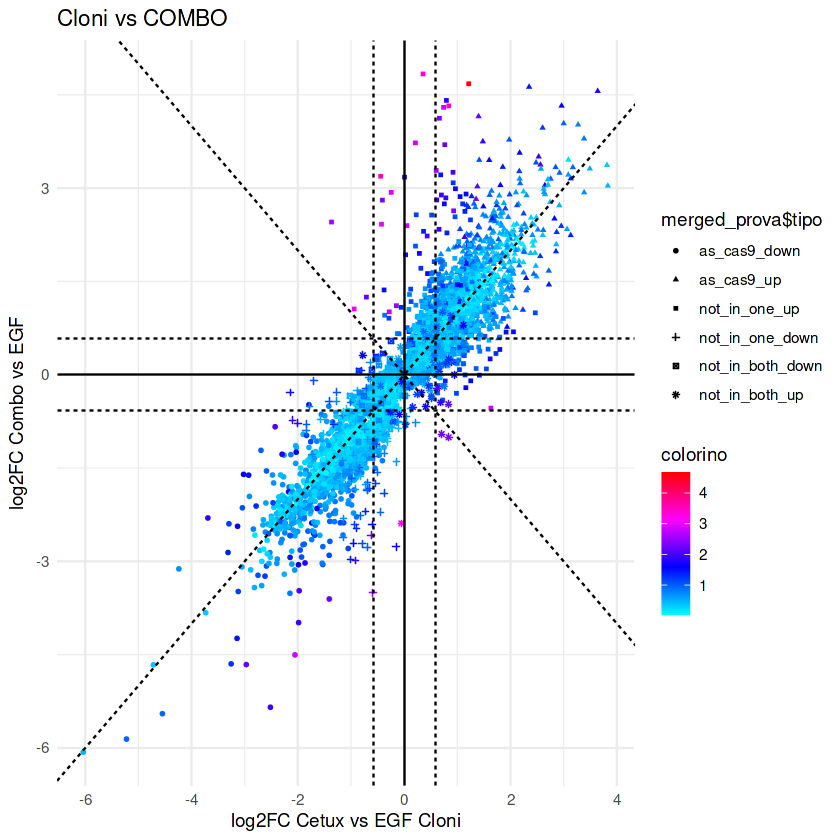

In [137]:
library(scales)
M <- max(abs(merged_prova$colorino), na.rm = TRUE)

# 2) palette "arcobaleno" speculare con bianco al centro
pal <- c( 
  "white",                                    # centro = 0
  rainbow(256, start = 0.5, end = 1)          # lato positivo
)

scatter_plot <- ggplot(merged_prova, aes(x = log2FC_CetuxvsEGF_cloni, 
                                   y = log2FC_CombovsEGF, 
                                   color = colorino,,shape = merged_prova$tipo)) +
  geom_point(size = 1) + 
  labs(title = 'Cloni vs COMBO',
       x = "log2FC Cetux vs EGF Cloni",
       y = "log2FC Combo vs EGF") +
  theme_minimal() +
  # Scala colore: simmetrica, bianco a 0, arcobaleno ai lati
  scale_colour_gradientn(colors = pal,
                         guide = "colourbar") +
  geom_hline(yintercept = 0, color = "black", size = 0.5) + 
  geom_vline(xintercept = 0, color = "black", size = 0.5) + 
  geom_abline(intercept = 0, slope = 1, color = "black", linetype = "dashed", size = 0.5) + 
  geom_abline(intercept = 0, slope = -1, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) + 
  geom_hline(yintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) 

print(scatter_plot)

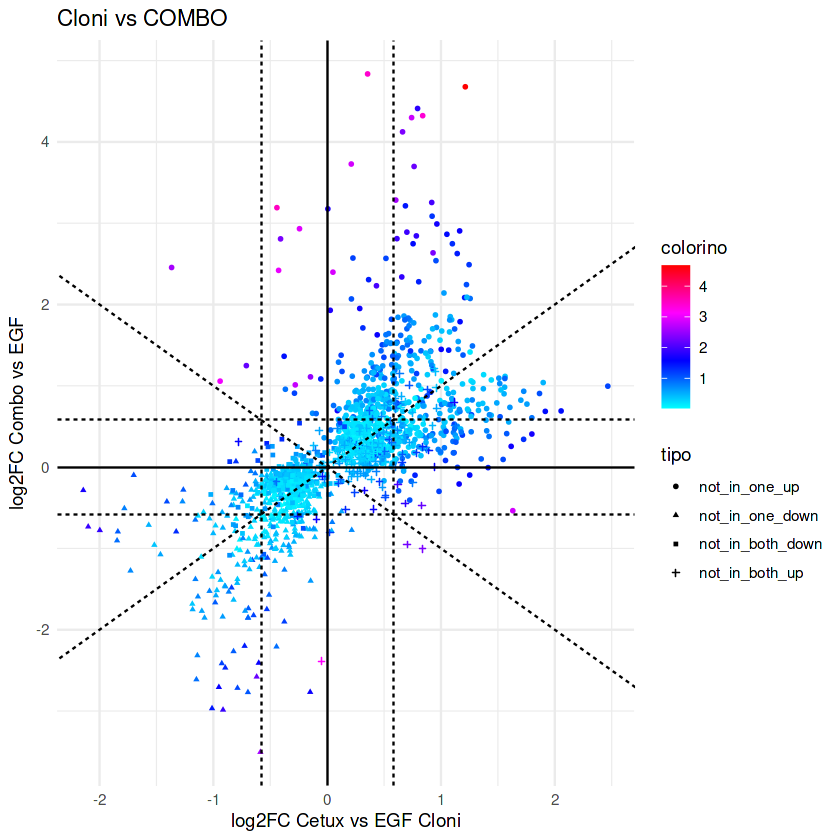

In [141]:
library(scales)
M <- max(abs(merged_culo$colorino), na.rm = TRUE)

# 2) palette "arcobaleno" speculare con bianco al centro
pal <- c( 
  "white",                                    # centro = 0
  rainbow(256, start = 0.5, end = 1)          # lato positivo
)

scatter_plot <- ggplot(merged_culo, aes(x = log2FC_CetuxvsEGF_cloni, 
                                   y = log2FC_CombovsEGF, 
                                   color = colorino,,shape = tipo)) +
  geom_point(size = 1) + 
  labs(title = 'Cloni vs COMBO',
       x = "log2FC Cetux vs EGF Cloni",
       y = "log2FC Combo vs EGF") +
  theme_minimal() +
  # Scala colore: simmetrica, bianco a 0, arcobaleno ai lati
  scale_colour_gradientn(colors = pal,
                         guide = "colourbar") +
  geom_hline(yintercept = 0, color = "black", size = 0.5) + 
  geom_vline(xintercept = 0, color = "black", size = 0.5) + 
  geom_abline(intercept = 0, slope = 1, color = "black", linetype = "dashed", size = 0.5) + 
  geom_abline(intercept = 0, slope = -1, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) + 
  geom_hline(yintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) 

print(scatter_plot)

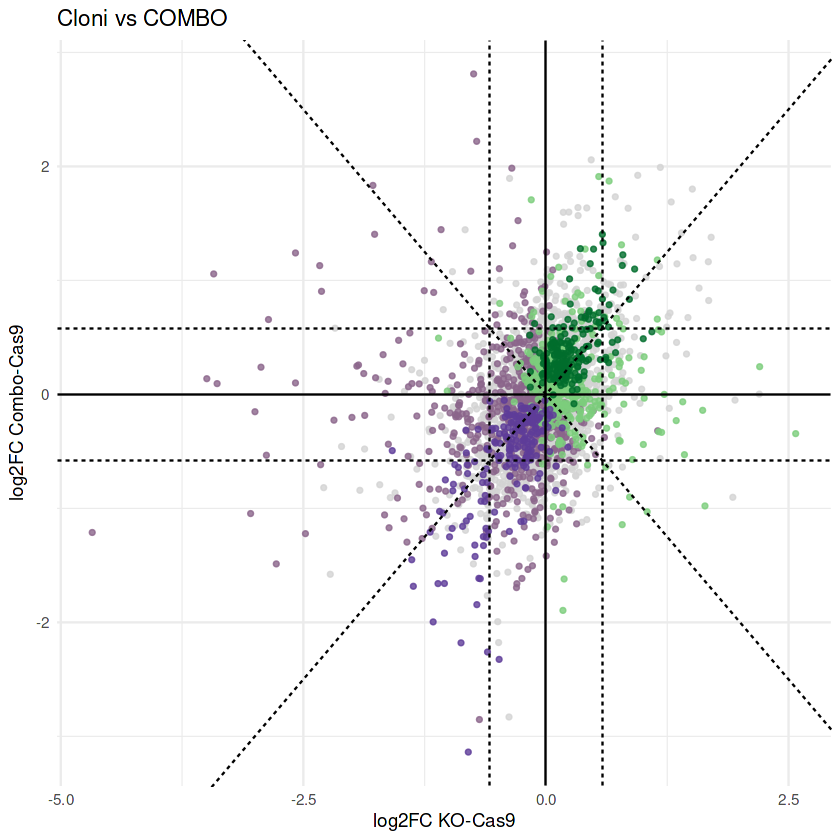

In [94]:
scatter_plot <- ggplot(merged_prova, aes(x = KOvsCas9, 
                                   y = CrenivsCas9, 
                                   color = tipo)) +
  geom_point(size = 1,alpha=0.8) + 
  labs(title = 'Cloni vs COMBO',
       x = "log2FC KO-Cas9",
       y = "log2FC Combo-Cas9") +
  theme_minimal() + 
  scale_color_manual(values = c(
    "as_cas9_down" = "lightgrey",
    "not_in_both_down" = "#006d2c",
    "as_cas9_up" = "lightgrey",
    "not_in_both_up" = "#5e3c99",
    "not_in_one_up"="plum4",
    "not_in_one_down"="palegreen3"  
  ))+
  geom_hline(yintercept = 0, color = "black", size = 0.5) + 
  geom_vline(xintercept = 0, color = "black", size = 0.5) + 
  geom_abline(intercept = 0, slope = 1, color = "black", linetype = "dashed", size = 0.5) + 
  geom_abline(intercept = 0, slope = -1, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) + 
  geom_hline(yintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) + theme(legend.position = "none")

#ggsave(scatter_plot,filename = 'fenocopia_degDEG.pdf')
print(scatter_plot)

`geom_smooth()` using formula = 'y ~ x'


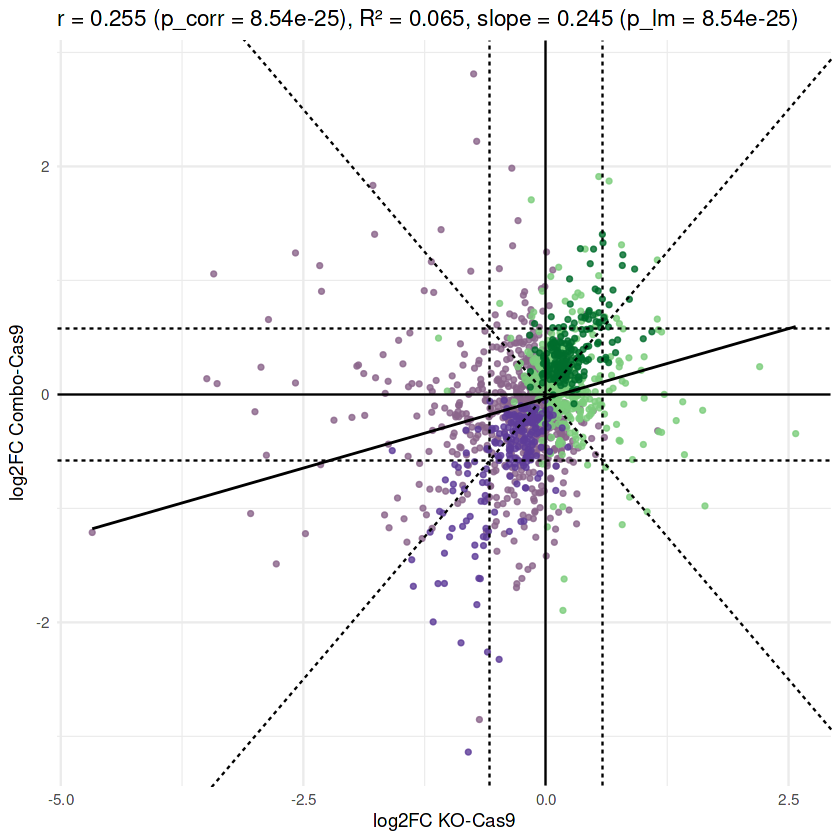

In [86]:
library(ggplot2)

## --- 1) dati filtrati: via i gruppi grigi + NA/Inf
df <- subset(merged_prova, !(tipo %in% c("as_cas9_down","as_cas9_up")))
df <- subset(df, is.finite(KOvsCas9) & is.finite(CrenivsCas9))
df$tipo <- droplevels(df$tipo)

## --- 2) statistiche
# correlazione di Pearson (con p-value)
ct      <- cor.test(df$KOvsCas9, df$CrenivsCas9, method = "pearson")
r       <- unname(ct$estimate)
p_corr  <- ct$p.value

# regressione lineare (pendenza ≠ 0)
fit     <- lm(CrenivsCas9 ~ KOvsCas9, data = df)
slope   <- unname(coef(fit)[2])
r2      <- summary(fit)$r.squared
p_lm    <- summary(fit)$coefficients[2,4]

# titolo con tutte le metriche
title_txt <- sprintf(
  "r = %.3f (p_corr = %.2e), R² = %.3f, slope = %.3f (p_lm = %.2e)",
  r, p_corr, r2, slope, p_lm
)

## --- 3) plot (punta e trendline calcolata sui dati filtrati)
scatter_plot <- ggplot(df, aes(x = KOvsCas9, y = CrenivsCas9, color = tipo)) +
  geom_point(size = 1, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, color = "black", size = 0.6) +
  labs(title = title_txt,
       x = "log2FC KO-Cas9",
       y = "log2FC Combo-Cas9") +
  theme_minimal() +
  scale_color_manual(values = c(
    "not_in_both_down" = "#006d2c",
    "not_in_both_up"   = "#5e3c99",
    "not_in_one_up"    = "plum4",
    "not_in_one_down"  = "palegreen3"
  ), drop = TRUE) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = 0, color = "black", size = 0.5) +
  geom_abline(intercept = 0, slope =  1, color = "black", linetype = "dashed", size = 0.5) +
  geom_abline(intercept = 0, slope = -1, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept =  0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept =  0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  theme(legend.position = "none")

print(scatter_plot)
# ggsave("fenocopia_degDEG_filtered.pdf", plot = scatter_plot, width = 6, height = 6)


`geom_smooth()` using formula = 'y ~ x'


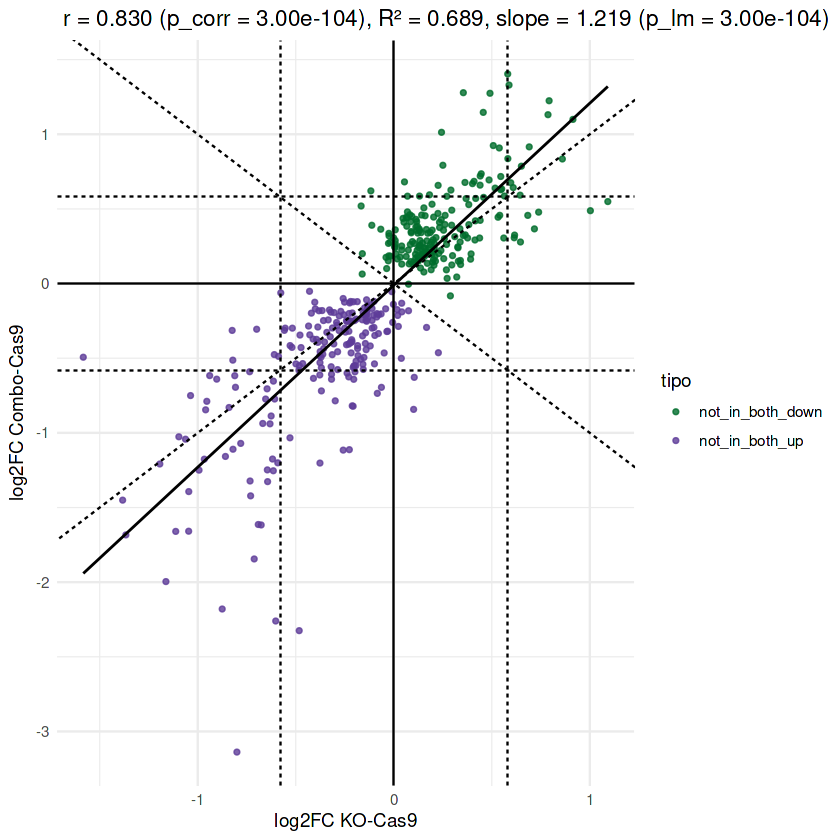

In [88]:
library(ggplot2)

## --- 1) filtro: tengo solo i gruppi verde e viola scuro
df <- subset(merged_prova, tipo %in% c("not_in_both_down", "not_in_both_up"))
df <- subset(df, is.finite(KOvsCas9) & is.finite(CrenivsCas9))
df$tipo <- droplevels(df$tipo)

## --- 2) statistiche globali sui due gruppi insieme
ct      <- cor.test(df$KOvsCas9, df$CrenivsCas9, method = "pearson")
r       <- unname(ct$estimate)
p_corr  <- ct$p.value

fit     <- lm(CrenivsCas9 ~ KOvsCas9, data = df)
slope   <- unname(coef(fit)[2])
r2      <- summary(fit)$r.squared
p_lm    <- summary(fit)$coefficients[2,4]

title_txt <- sprintf(
  " r = %.3f (p_corr = %.2e), R² = %.3f, slope = %.3f (p_lm = %.2e)",
  r, p_corr, r2, slope, p_lm
)

## --- 3) grafico
scatter_plot <- ggplot(df, aes(x = KOvsCas9, y = CrenivsCas9, color = tipo)) +
  geom_point(size = 1, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, color = "black", size = 0.6) +
  labs(title = title_txt,
       x = "log2FC KO-Cas9",
       y = "log2FC Combo-Cas9") +
  theme_minimal() +
  scale_color_manual(values = c(
    "not_in_both_down" = "#006d2c",
    "not_in_both_up"   = "#5e3c99"
  )) +
  geom_hline(yintercept = 0, color = "black", size = 0.5) +
  geom_vline(xintercept = 0, color = "black", size = 0.5) +
  geom_abline(intercept = 0, slope =  1, color = "black", linetype = "dashed", size = 0.5) +
  geom_abline(intercept = 0, slope = -1, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept =  0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept =  0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = -0.58, color = "black", linetype = "dashed", size = 0.5)

print(scatter_plot)
# ggsave("fenocopia_degDEG_verde_viola.pdf", plot = scatter_plot, width = 6, height = 6)


,Row.names,log2FC_CombovsEGF,log2FC_CetuxvsEGF_cloni,tipo,log2FoldChange,CrenivsCas9,KOvsCas9
,<I<chr>>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>
15,ABCB7,-0.07488532,-0.116815440,not_in_both_down,-0.3748168,0.29993151,0.25800139
85,AC010616.1,-0.34058450,-0.257252406,not_in_both_down,-0.7977515,0.45716698,0.54049908
163,AC104958.2,-0.59511284,-0.227354689,not_in_both_down,-0.8736039,0.27849103,0.64624917
197,ACAA2,0.14586195,-0.233232726,not_in_both_down,-0.3151489,0.46101081,0.08191614
213,ACOT4,0.01491351,-0.299286664,not_in_both_down,-0.6624885,0.67740201,0.36320184
223,ACSS2,0.14902298,-0.477483017,not_in_both_down,-0.5320640,0.68108701,0.05458102
268,ADIPOR1,-0.19800399,-0.362453513,not_in_both_down,-0.4669035,0.26889950,0.10444997
290,AGPAT2,-0.16552863,-0.366902565,not_in_both_down,-0.5065987,0.34107011,0.13969618
312,AK7,-0.03782665,-0.292778830,not_in_both_down,-0.8747093,0.83688268,0.58193050


In [61]:
unique(merged_prova$tipo)

[1] as_cas9_down     as_cas9_up       not_in_one_up    not_in_one_down 
[5] not_in_both_down not_in_both_up  
6 Levels: as_cas9_down as_cas9_up not_in_one_up ... not_in_both_up

          cas9-ko
cas9-combo not_in   in
    not_in    206  251
    in        461 1948


[1] 7.025995e-30

          cas9-ko
cas9-combo not_in   in
    not_in    199  174
    in        289 2692


── Attaching core tidyverse packages ──────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] 1.903959e-104


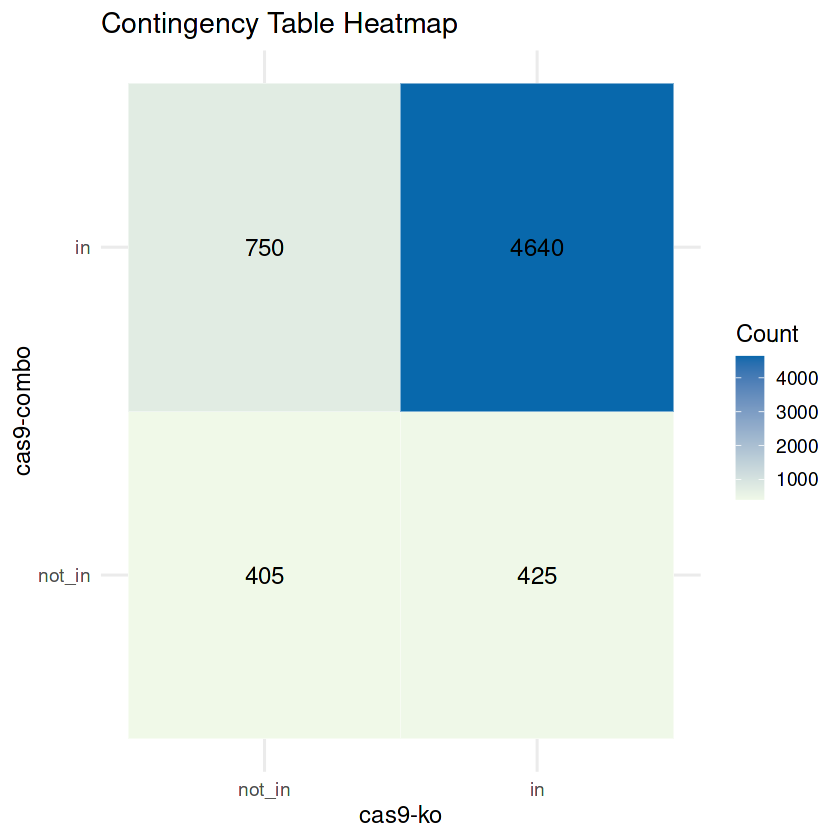

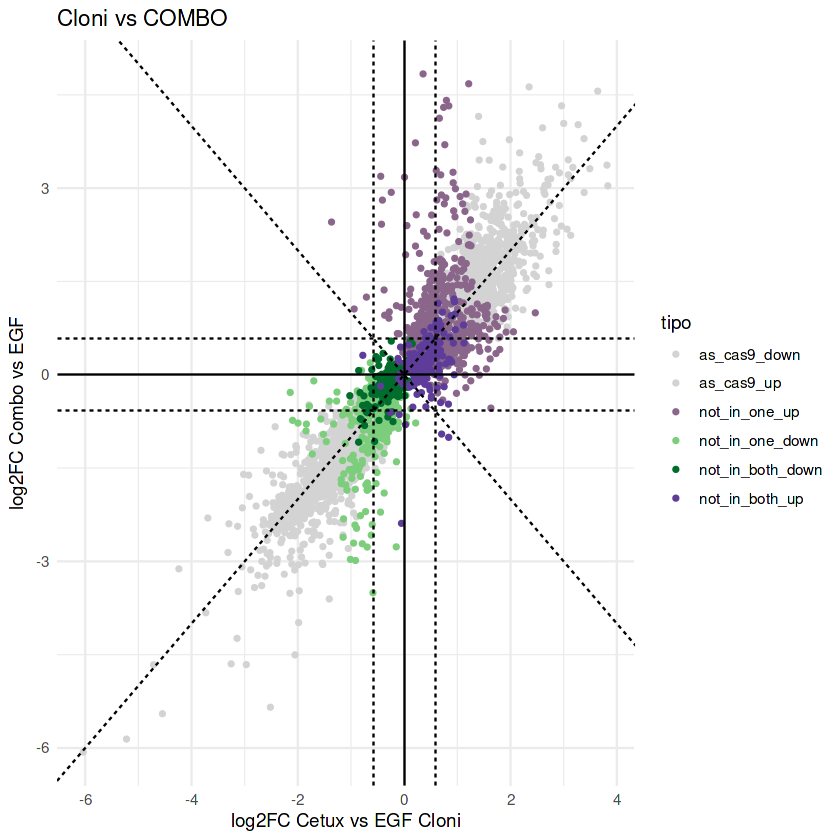

In [44]:
cas9_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_ko_2025/cetux_vs_egf_no3/trattamento_cutoff0.05-CETUX.vs.EGF0.1.deseq2.tsv'
#ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/327_creni_vs_EGF/trattamento_cutoff0.05-Creni_5uM_72h.vs.EGF0.1.deseq2.tsv'
cas9<-read.table(cas9_path,stringsAsFactors = FALSE, header = TRUE,row.names = 1)

creni_path_322<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/322_combo_vs_EGF/trattamento_cutoff0.05-Combo_72h.vs.EGF0.1.deseq2.tsv'
creni<-read.table(creni_path_322,stringsAsFactors = FALSE, header = TRUE,row.names = 1)
ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_ko_2025/cloni_cetux_vs_egf/trattamento_cutoff0.05-CETUX.vs.EGF0.1.deseq2.tsv'
#ko_path<-'/mnt/cold1/snaketree/prj/DE_RNASeq/dataset/Ire_Creni/327_creni_vs_EGF/trattamento_cutoff0.05-Creni_5uM_72h.vs.EGF0.1.deseq2.tsv'
ko<-read.table(ko_path,stringsAsFactors = FALSE, header = TRUE,row.names = 1)

th_padj<-0.05
th_log2fc<-0

#selezioni i geni che sono significativi  nella cas9 cetux vs egf
cas9_up<-row.names(cas9[cas9$padj<th_padj &cas9$log2FoldChange>th_log2fc,]) 
cas9_down<-row.names(cas9[cas9$padj<th_padj &cas9$log2FoldChange<th_log2fc,])
all_cas9<-union(cas9_up,cas9_down)
#geni che si muovono up e down in combo
combo_up<-row.names(creni[creni$padj<th_padj &creni$log2FoldChange>th_log2fc,])
combo_down<-row.names(creni[creni$padj<th_padj &creni$log2FoldChange<th_log2fc,])
all_combo<-union(combo_up,combo_down)
#geni che si muovono in ko up e down
ko_up<-row.names(ko[ko$padj<th_padj &ko$log2FoldChange>th_log2fc,])
ko_down<-row.names(ko[ko$padj<th_padj &ko$log2FoldChange<th_log2fc,])
all_ko<-union(ko_up,ko_down)

##$$$$$$$$$$$$$$$$$$$$$$$$$$# logica Sofi originale su soli up rifatta
# universo: tutti i geni con dati nei confronti
universe_up <- intersect(cas9_up, intersect(rownames(ko), rownames(creni)))

# geni che si muovono in cas9 ma non in combo
cas9_combo_up <- setdiff(universe_up, combo_up)

# geni che si muovono in cas9 ma non in ko
cas9_ko_up <- setdiff(universe_up, ko_up)
#intersezioni
cas9_ko_common<-setdiff(universe_up,cas9_ko_up)
cas9_combo_common<-setdiff(universe_up,cas9_combo_up)


up_ns <-intersect(cas9_combo_up, cas9_ko_up)
a_up <-intersect(cas9_combo_up, cas9_ko_up)#si muovono solo in cas9 no ko no combo in entrambi
b_up <-  setdiff(cas9_combo_up,a_up)                           # solo in cas9-combo si muovono in cas9 ma non in combo
c_up <- setdiff(cas9_ko_up, a_up)                        # solo in cas9 ma non in ko, si muovono in cas9 ma non in ko
d_up <- setdiff(universe_up, union(union(a_up,b_up),c_up))       # 

contingency_table_up <- matrix(c(length(a_up), length(b_up), length(c_up),length( d_up)), nrow = 2, byrow=T,
                            dimnames = list("cas9-combo" = c("not_in", "in"),
                                            "cas9-ko" = c("not_in", "in")))

print(contingency_table_up)
prova<-fisher.test(contingency_table_up,alternative = 'greater')
prova$p.value
#DOWN 
# universo: tutti i geni con dati nei confronti
universe_down <- intersect(cas9_down, intersect(rownames(ko), rownames(creni)))

# geni che si muovono in cas9 ma non in combo
cas9_combo_down <- setdiff(universe_down, combo_down)
 
# geni che si muovono in cas9 ma non in ko
cas9_ko_down <- setdiff(universe_down, ko_down)


a_down <-intersect(cas9_combo_down, cas9_ko_down)#si muovono solo in cas9 no ko no combo in entrambi
b_down <-  setdiff(cas9_combo_down,a_down)                           # solo in cas9-combo si muovono in cas9 ma non in combo
c_down <- setdiff(cas9_ko_down, a_down)                        # solo in cas9 ma non in ko, si muovono in cas9 ma non in ko
d_down <- setdiff(universe_down, union(union(a_down,b_down),c_down))       # 

contingency_table_down <- matrix(c(length(a_down), length(b_down), length(c_down),length( d_down)), nrow = 2, byrow=T,
                            dimnames = list("cas9-combo" = c("not_in", "in"),
                                            "cas9-ko" = c("not_in", "in")))

print(contingency_table_down)


#fisher totale


contingency_table <- matrix(c(length(a_up)+length(a_down), length(b_up)+length(b_down), length(c_up)+length(c_down),length(d_up)+length(d_down)), nrow = 2, byrow=T,
                                 dimnames = list("cas9-combo" = c("not_in", "in"),
                                                 "cas9-ko" = c("not_in", "in")))



library(tidyverse)

df_long <- as.data.frame(as.table(contingency_table))
colnames(df_long) <- c("cas9_combo", "cas9_ko", "Freq")
ggplot(df_long, aes(x = cas9_ko, y = cas9_combo, fill = Freq)) +
  geom_tile(color = "white") +
  geom_text(aes(label = Freq), color = "black", size = 5) +
  scale_fill_gradient(low = "#f0f9e8", high = "#0868ac") +
  labs(
    title = "Contingency Table Heatmap",
    x = "cas9-ko",
    y = "cas9-combo",
    fill = "Count"
  ) +
  theme_minimal(base_size = 14)
# Test di Fisher
fisher_result <- fisher.test(contingency_table,alternative = 'greater')
print(fisher_result$p.value)


#heatmap 

creni <- creni[, 'log2FoldChange', drop = FALSE]
ko <- ko[, 'log2FoldChange', drop = FALSE]


colnames(creni)<-'log2FC_CombovsEGF'
colnames(ko)<-'log2FC_CetuxvsEGF_cloni'
merged<-merge(creni,ko,by='row.names')
merged[is.na(merged)] <- 0
row.names(merged)<-merged$Row.names
merged$Row.names<-NULL
paneth_genes<-c('ATOH1','DLL1','DEFA5','GFI1','HES1')

universe<-union(universe_up,universe_down)
merged<-merged[universe,]
merged$tipo<-ifelse(rownames(merged)%in%a_up,'not_in_both_up',
                      ifelse(rownames(merged) %in% a_down,'not_in_both_down',ifelse(rownames(merged)%in% union(b_up,c_up),'not_in_one_up',ifelse(rownames(merged)%in% union(b_down,c_down),'not_in_one_down',ifelse(rownames(merged) %in% universe_up,'as_cas9_up','as_cas9_down')))))
merged$tipo <- factor(merged$tipo, levels = c("as_cas9_down", "as_cas9_up", 'not_in_one_up','not_in_one_down',"not_in_both_down", "not_in_both_up"))
merged <- merged[order(as.numeric(merged$tipo)), ]

scatter_plot <- ggplot(merged, aes(x = log2FC_CetuxvsEGF_cloni, 
                                   y = log2FC_CombovsEGF, 
                                   color = tipo)) +
  geom_point(size = 1) + 
  labs(title = 'Cloni vs COMBO',
       x = "log2FC Cetux vs EGF Cloni",
       y = "log2FC Combo vs EGF") +
  theme_minimal() + 
  scale_color_manual(values = c(
    "as_cas9_down" = "lightgrey",
    "not_in_both_down" = "#006d2c",
    "as_cas9_up" = "lightgrey",
    "not_in_both_up" = "#5e3c99",
    "not_in_one_up"="plum4",
    "not_in_one_down"="palegreen3"
    
    
  ))+
  geom_hline(yintercept = 0, color = "black", size = 0.5) + 
  geom_vline(xintercept = 0, color = "black", size = 0.5) + 
  geom_abline(intercept = 0, slope = 1, color = "black", linetype = "dashed", size = 0.5) + 
  geom_abline(intercept = 0, slope = -1, color = "black", linetype = "dashed", size = 0.5) +
  geom_hline(yintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) + 
  geom_hline(yintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = 0.58, color = "black", linetype = "dashed", size = 0.5) +
  geom_vline(xintercept = -0.58, color = "black", linetype = "dashed", size = 0.5) 

print(scatter_plot)